# create routing for calling a condition

In our last chail_tool_tool_Calling notebook We saw that the graph can:

- Return a tool call
- Return a natural language response

## Lets build a router graph:

<img src="../Images/router_graph.png" width="650" height="500">

### Goal:
(1) Add a node that will call our tool.

(2) Add a conditional edge that will look at the chat model output, and route to our tool calling node or simply end if no tool call is performed.

In [2]:
# Check virtual envirnment path is set

import sys
#sys.executable

In [6]:
# load api key
from dotenv import load_dotenv
import os

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

In [9]:
# Configure google‑genai (the new SDK)

from google import genai

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

'''for model in client.models.list():
    print(model.name) '''

'for model in client.models.list():\n    print(model.name) '

In [12]:
# Build llm model
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

result = llm.invoke("Hi What can you do?")
print(result.content)

Hi there! I'm a large language model, trained by Google.

Essentially, I'm designed to understand and generate human-like text. This means I can do quite a lot, including:

1.  **Answer Questions:** I can provide information on a vast range of topics, from science and history to current events (up to my last training update) and pop culture.
2.  **Generate Text:** I can write stories, poems, code, scripts, musical pieces, email, letters, articles, blog posts, and many other forms of creative or functional content.
3.  **Summarize Information:** Give me a long article or document, and I can condense it into key points.
4.  **Explain Complex Concepts:** I can break down difficult ideas into simpler terms.
5.  **Translate Languages:** I can translate text between various languages.
6.  **Brainstorm Ideas:** Need help coming up with ideas for a project, a story, or a solution to a problem? I can assist.
7.  **Help with Writing Tasks:** I can proofread, edit, suggest improvements, or help y

## Create a tool and bind to LLM 

In [17]:
# create a tool to check if number is even
def check_even(num :int):
    "check if number is even"
    if num % 2 == 0 :
        return "Even"
    else:
        return "Odd"

e = check_even(3)
e

'Odd'

In [18]:
# bind tool to llm
llm_with_tools = llm.bind_tools([check_even])

In [23]:
# bind tool to llm
check = llm_with_tools.invoke("Check if 34556is even")
check.tool_calls

[{'name': 'check_even',
  'args': {'num': 34556},
  'id': '7e131336-8fd5-4a44-ac10-5cc43a9fc28b',
  'type': 'tool_call'}]

## Use built in MessagesState, toolNode and toolCondition
This node:

    reads the last AI message
    checks if it contains tool_calls
    finds the matching tool
    executes it
    returns a ToolMessage

ToolNode gives you:

    automatic argument validation
    automatic error handling
    automatic multiple tool support
    automatic multiple tool calls in one message
    no need to write your own router
    no need to write your own executor
    It’s the recommended way to build tool‑calling graphs in LangGraph.

In [19]:
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [20]:
# Create Node1 function

def call_llm(state : MessagesState):
    response = llm_with_tools.invoke(state['messages'])
    return {'messages' : [response]}
    

## Build graph

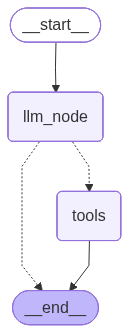

In [28]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(MessagesState)

# add nodes

builder.add_node('llm_node', call_llm)
builder.add_node('tools', ToolNode([check_even])) # built in object uses node name 'tools'

# add edges with router
builder.add_edge(START , 'llm_node')
builder.add_conditional_edges('llm_node',tools_condition, )
builder.add_edge('tools' , END)

# compile
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

                 

In [31]:

graph.invoke({'messages':["What can you do?"]})

{'messages': [HumanMessage(content='What can you do?', additional_kwargs={}, response_metadata={}, id='a4164d9d-94b6-44a9-b30e-7b67af900a77'),
  AIMessage(content='I can check if a number is even.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d9372-d865-7330-8991-c6c79dca8359-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 9, 'total_tokens': 52, 'input_token_details': {'cache_read': 0}})]}

In [34]:
from langchain_core.messages import HumanMessage
result = graph.invoke({'messages':[HumanMessage(role= "user", content ="the number 76534 is odd or even?", name = 'Diya')]})
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================
Name: Diya

the number 76534 is odd or even?
================================== Ai Message ==================================
Tool Calls:
  check_even (144d5848-c0e1-4209-8735-0ff184e7206d)
 Call ID: 144d5848-c0e1-4209-8735-0ff184e7206d
  Args:
    num: 76534
================================= Tool Message =================================
Name: check_even

Even
